In [1]:
import pandas as pd
from pipeline import create_X_y_df
import numpy as np
from datetime import timedelta

In [2]:
full_dataset_df = pd.read_parquet("../../data/churn-prediction-25-26/train.parquet")

In [3]:
df = full_dataset_df.copy()

In [4]:
# Second Train Test set
cut_off_date_train = pd.Timestamp("2018-11-05")
cut_off_date_test = pd.Timestamp("2018-11-15")

df_X, df_y = create_X_y_df(df = df,
                                t0=cut_off_date_train,
                                t1=cut_off_date_test)

In [5]:
df_X["date"] = pd.to_datetime(df_X["time"]).dt.date

df_X = df_X.sort_values(["userId", "time"])

df_X_1 = df_X.groupby(["userId", "date"])["length"].sum().reset_index()

In [6]:
start_date = df_X_1["date"].min()
end_date = df_X_1["date"].max()

In [8]:
df_user_id_date = pd.DataFrame()

In [9]:
df_user_id_date["userId"] = df_X_1["userId"].unique()

In [11]:
df_merge_days = pd.DataFrame()

df_merge_days["date"] = np.arange(start_date, end_date + timedelta(days = 1), timedelta(days = 1))

In [13]:
df_merge_days["date"] = pd.to_datetime(df_merge_days["date"]).dt.date

In [14]:
df_user_id_days = df_user_id_date.merge(df_merge_days, how="cross")

In [15]:
df_user_id_days

,userId,date
0,1000035,2018-10-01
1,1000035,2018-10-02
2,1000035,2018-10-03
3,1000035,2018-10-04
4,1000035,2018-10-05
...,...,...
555583,1999905,2018-11-01
555584,1999905,2018-11-02
555585,1999905,2018-11-03
555586,1999905,2018-11-04


In [54]:
df_X_1_merge = df_X_1.merge(df_user_id_days, on = ["userId", "date"], how="right")

In [55]:
df_X_1_merge["date"] = pd.to_datetime(df_X_1_merge["date"])

In [56]:
df_X_1_merge.sample(10)

,userId,date,length
56100,1101542,2018-10-13,NaN
93189,1165971,2018-10-22,NaN
248541,1446796,2018-11-03,NaN
367310,1660327,2018-10-03,55018.55635
259318,1465753,2018-10-11,NaN
30518,1054109,2018-10-27,NaN
60539,1108512,2018-10-24,2326.35583
389197,1697647,2018-10-02,NaN
496780,1893625,2018-10-17,NaN
443702,1792959,2018-10-03,NaN


In [57]:
df_X_1_merge["length"] = df_X_1_merge["length"].fillna(0.0)

In [58]:
df_X_1_merge

,userId,date,length
0,1000035,2018-10-01,0.00000
1,1000035,2018-10-02,0.00000
2,1000035,2018-10-03,0.00000
3,1000035,2018-10-04,0.00000
4,1000035,2018-10-05,625.63129
...,...,...,...
555583,1999905,2018-11-01,0.00000
555584,1999905,2018-11-02,0.00000
555585,1999905,2018-11-03,0.00000
555586,1999905,2018-11-04,0.00000


In [59]:
df_X_1_merge = df_X_1_merge.sort_values(["userId", "date"], ascending=True)

In [60]:
df_X_1_merge["rolling_avg"] = df_X_1_merge.groupby(["userId"])["length"].\
    transform(lambda s: s.rolling(window = 4).mean())

In [61]:
df_X_1_merge

,userId,date,length,rolling_avg
0,1000035,2018-10-01,0.00000,NaN
1,1000035,2018-10-02,0.00000,NaN
2,1000035,2018-10-03,0.00000,NaN
3,1000035,2018-10-04,0.00000,0.000000
4,1000035,2018-10-05,625.63129,156.407823
...,...,...,...,...
555583,1999905,2018-11-01,0.00000,2524.338198
555584,1999905,2018-11-02,0.00000,2524.338198
555585,1999905,2018-11-03,0.00000,2524.338198
555586,1999905,2018-11-04,0.00000,0.000000


In [62]:
#df_X_1_merge[pd.isna(df_X_1_merge["rolling_avg"])]["rolling_avg"] = df_X_1_merge.groupby(["userId"])

df_temp = df_X_1_merge[~pd.isna(df_X_1_merge["rolling_avg"])].groupby(["userId"])["date"].min()


df_first_rolling_avg = df_X_1_merge.merge(df_temp, on=["userId", "date"])

In [63]:
df_first_rolling_avg

,userId,date,length,rolling_avg
0,1000035,2018-10-04,0.00000,0.000000
1,1000103,2018-10-04,9769.04682,2442.261705
2,1000164,2018-10-04,0.00000,56.855398
3,1000168,2018-10-04,9864.81080,2466.202700
4,1000182,2018-10-04,0.00000,0.000000
...,...,...,...,...
15428,1999241,2018-10-04,0.00000,1928.982380
15429,1999382,2018-10-04,0.00000,2106.308208
15430,1999781,2018-10-04,0.00000,20226.307082
15431,1999848,2018-10-04,14956.06974,6358.343285


In [64]:
df_first_rolling_avg_dropped = df_first_rolling_avg[["userId", "rolling_avg"]]

In [65]:
df_X_1_merge = df_X_1_merge.merge(df_first_rolling_avg_dropped, on = "userId")

In [66]:
df_X_1_merge

,userId,date,length,rolling_avg_x,rolling_avg_y
0,1000035,2018-10-01,0.00000,NaN,0.0
1,1000035,2018-10-02,0.00000,NaN,0.0
2,1000035,2018-10-03,0.00000,NaN,0.0
3,1000035,2018-10-04,0.00000,0.000000,0.0
4,1000035,2018-10-05,625.63129,156.407823,0.0
...,...,...,...,...,...
555583,1999905,2018-11-01,0.00000,2524.338198,0.0
555584,1999905,2018-11-02,0.00000,2524.338198,0.0
555585,1999905,2018-11-03,0.00000,2524.338198,0.0
555586,1999905,2018-11-04,0.00000,0.000000,0.0


In [67]:

mask = df_X_1_merge["rolling_avg_x"].isna()
df_X_1_merge.loc[mask, "rolling_avg_x"] = df_X_1_merge.loc[mask, "rolling_avg_y"]


#df_X_1_merge[pd.isna(df_X_1_merge["rolling_avg_x"])]["rolling_avg_x"] = df_X_1_merge[pd.isna(df_X_1_merge["rolling_avg_x"])]["rolling_avg_y"]

In [68]:
df_X_1_merge

,userId,date,length,rolling_avg_x,rolling_avg_y
0,1000035,2018-10-01,0.00000,0.000000,0.0
1,1000035,2018-10-02,0.00000,0.000000,0.0
2,1000035,2018-10-03,0.00000,0.000000,0.0
3,1000035,2018-10-04,0.00000,0.000000,0.0
4,1000035,2018-10-05,625.63129,156.407823,0.0
...,...,...,...,...,...
555583,1999905,2018-11-01,0.00000,2524.338198,0.0
555584,1999905,2018-11-02,0.00000,2524.338198,0.0
555585,1999905,2018-11-03,0.00000,2524.338198,0.0
555586,1999905,2018-11-04,0.00000,0.000000,0.0


In [69]:
df_X_1_merge = df_X_1_merge[["userId", "date", "length", "rolling_avg_x"]]

In [70]:
df_X_1_merge = df_X_1_merge.rename(columns={"rolling_avg_x" : "rolling_avg"})

In [71]:
df_X_1_merge

,userId,date,length,rolling_avg
0,1000035,2018-10-01,0.00000,0.000000
1,1000035,2018-10-02,0.00000,0.000000
2,1000035,2018-10-03,0.00000,0.000000
3,1000035,2018-10-04,0.00000,0.000000
4,1000035,2018-10-05,625.63129,156.407823
...,...,...,...,...
555583,1999905,2018-11-01,0.00000,2524.338198
555584,1999905,2018-11-02,0.00000,2524.338198
555585,1999905,2018-11-03,0.00000,2524.338198
555586,1999905,2018-11-04,0.00000,0.000000


In [72]:
#df_X_1_merge["week_number"] = df_X_1_merge["date"].dt.isocalendar().week

df_X_1_merge["date"] = pd.to_datetime(df_X_1_merge["date"])

In [74]:
df_X_1_merge["week_number"] = df_X_1_merge["date"].dt.isocalendar().week

In [75]:
df_X_1_merge

,userId,date,length,rolling_avg,week_number
0,1000035,2018-10-01,0.00000,0.000000,40
1,1000035,2018-10-02,0.00000,0.000000,40
2,1000035,2018-10-03,0.00000,0.000000,40
3,1000035,2018-10-04,0.00000,0.000000,40
4,1000035,2018-10-05,625.63129,156.407823,40
...,...,...,...,...,...
555583,1999905,2018-11-01,0.00000,2524.338198,44
555584,1999905,2018-11-02,0.00000,2524.338198,44
555585,1999905,2018-11-03,0.00000,2524.338198,44
555586,1999905,2018-11-04,0.00000,0.000000,44


In [76]:
df_X_1_merge["weekly_average"] = df_X_1_merge.groupby(["userId", "week_number"])["rolling_avg"].transform("mean")

In [77]:
df_X_1_merge

,userId,date,length,rolling_avg,week_number,weekly_average
0,1000035,2018-10-01,0.00000,0.000000,40,67.031924
1,1000035,2018-10-02,0.00000,0.000000,40,67.031924
2,1000035,2018-10-03,0.00000,0.000000,40,67.031924
3,1000035,2018-10-04,0.00000,0.000000,40,67.031924
4,1000035,2018-10-05,625.63129,156.407823,40,67.031924
...,...,...,...,...,...,...
555583,1999905,2018-11-01,0.00000,2524.338198,44,1718.994804
555584,1999905,2018-11-02,0.00000,2524.338198,44,1718.994804
555585,1999905,2018-11-03,0.00000,2524.338198,44,1718.994804
555586,1999905,2018-11-04,0.00000,0.000000,44,1718.994804


In [84]:
df_weekly_avg_time = df_X_1_merge[["userId", "week_number", "weekly_average"]].drop_duplicates()

In [85]:
df_weekly_avg_time = df_weekly_avg_time.sort_values(["userId", "week_number"], ascending=False)

In [82]:
# Compute differences
#df_weekly_avg_time = df_weekly_avg_time[df_weekly_avg_time["week_number"] != 45]


#df_weekly_avg_time["delta_week_before"] = df_weekly_avg_time.groupby(["userId"])["weekly_average"].diff(1)

In [86]:
df_weekly_avg_time = df_weekly_avg_time.pivot(index = "userId", columns="week_number", values = "weekly_average")
cols = df_weekly_avg_time.columns

In [88]:
cols

Index([40, 41, 42, 43, 44, 45], dtype='UInt32', name='week_number')

In [87]:
df_weekly_avg_time

week_number,40,41,42,43,44,45
userId,,,,,,
1000035,67.031924,2324.556103,9592.823503,7576.029159,6107.531961,3287.523788
1000103,2442.261705,0.000000,0.000000,300.171497,100.057166,0.000000
1000164,51.911756,4129.249891,7189.057606,1122.994641,628.672950,0.000000
1000168,3500.750395,4498.733761,5246.588110,118.202005,0.000000,0.000000
1000182,0.000000,0.000000,1344.070110,2560.594153,2490.047782,10565.870882
...,...,...,...,...,...,...
1999241,1377.844557,0.000000,1351.319484,4617.234743,1519.984027,0.000000
1999382,1805.407035,0.000000,0.000000,0.000000,0.000000,0.000000
1999781,14359.895913,3599.188684,4180.787605,8271.014831,39866.309191,29292.619063


In [93]:
#df_weekly_avg_time[40]

delta_week_cols = []
for i, week_number in enumerate(cols):
    if i == len(cols) - 1:
        continue
    else:
        delta_week_cols.append(f"delta_week_{cols[-1]}_{week_number}")
        df_weekly_avg_time[f"delta_week_{cols[-1]}_{week_number}"] = df_weekly_avg_time[cols[-1]] - df_weekly_avg_time[week_number]

df_c = df_weekly_avg_time.copy()


#df_weekly_avg_time[40]

delta_percentage_cols = []
for i, week_number in enumerate(cols):
    if i == len(cols) - 1:
        continue
    else:
        delta_percentage_cols.append(f"%_delta_week_{cols[-1]}_{week_number}")
        df_weekly_avg_time[f"%_delta_week_{cols[-1]}_{week_number}"] = ((df_weekly_avg_time[cols[-1]] - df_weekly_avg_time[week_number]) / df_weekly_avg_time[week_number]) * 100


df_weekly_avg_time = df_weekly_avg_time.fillna(0.0)
df_weekly_avg_time = df_weekly_avg_time.replace(np.inf, None)

df_d = df_weekly_avg_time.copy()

In [94]:
df_weekly_avg_time

week_number,40,41,42,43,44,45,delta_week_45_40,delta_week_45_41,delta_week_45_42,delta_week_45_43,delta_week_45_44,%_delta_week_45_40,%_delta_week_45_41,%_delta_week_45_42,%_delta_week_45_43,%_delta_week_45_44
userId,,,,,,,,,,,,,,,,
1000035,67.031924,2324.556103,9592.823503,7576.029159,6107.531961,3287.523788,3220.491864,962.967684,-6305.299715,-4288.505371,-2820.008174,4804.415083,41.425874,-65.729341,-56.606242,-46.172631
1000103,2442.261705,0.000000,0.000000,300.171497,100.057166,0.000000,-2442.261705,0.000000,0.000000,-300.171497,-100.057166,-100.0,0.0,0.0,-100.0,-100.000000
1000164,51.911756,4129.249891,7189.057606,1122.994641,628.672950,0.000000,-51.911756,-4129.249891,-7189.057606,-1122.994641,-628.672950,-100.0,-100.0,-100.0,-100.0,-100.000000
1000168,3500.750395,4498.733761,5246.588110,118.202005,0.000000,0.000000,-3500.750395,-4498.733761,-5246.588110,-118.202005,0.000000,-100.0,-100.0,-100.0,-100.0,0.000000
1000182,0.000000,0.000000,1344.070110,2560.594153,2490.047782,10565.870882,10565.870882,10565.870882,9221.800773,8005.276729,8075.823101,None,None,686.1101,312.633563,324.324021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999241,1377.844557,0.000000,1351.319484,4617.234743,1519.984027,0.000000,-1377.844557,0.000000,-1351.319484,-4617.234743,-1519.984027,-100.0,0.0,-100.0,-100.0,-100.000000
1999382,1805.407035,0.000000,0.000000,0.000000,0.000000,0.000000,-1805.407035,0.000000,0.000000,0.000000,0.000000,-100.0,0.0,0.0,0.0,0.000000
1999781,14359.895913,3599.188684,4180.787605,8271.014831,39866.309191,29292.619063,14932.723149,25693.430379,25111.831458,21021.604232,-10573.690129,103.989077,713.867281,600.648343,254.159915,-26.522872


In [96]:
df_weekly_avg_time["mean_weekly_usage"] = df_weekly_avg_time[cols].mean(axis=1)
df_weekly_avg_time["median_weekly_usage"] = df_weekly_avg_time[cols].median(axis=1)
df_weekly_avg_time["var_weekly_usage"] = df_weekly_avg_time[cols].var(axis=1)

In [95]:
df_weekly_avg_time["mean_weekly_delta"] = df_weekly_avg_time[delta_week_cols].mean(axis=1)
df_weekly_avg_time["median_weekly_delta"] = df_weekly_avg_time[delta_week_cols].median(axis=1)
df_weekly_avg_time["var_weekly_delta"] = df_weekly_avg_time[delta_week_cols].var(axis=1)

In [98]:
df_weekly_avg_time["mean_weekly_delta_%"] = df_weekly_avg_time[delta_percentage_cols].mean(axis=1)
df_weekly_avg_time["median_weekly_delta_%"] = df_weekly_avg_time[delta_percentage_cols].median(axis=1)
df_weekly_avg_time["var_weekly_delta_%"] = df_weekly_avg_time[delta_percentage_cols].var(axis=1)

In [99]:
df_weekly_avg_time

week_number,40,41,42,43,44,45,delta_week_45_40,delta_week_45_41,delta_week_45_42,delta_week_45_43,...,%_delta_week_45_44,mean_weekly_delta,median_weekly_delta,var_weekly_delta,mean_weekly_usage,median_weekly_usage,var_weekly_usage,mean_weekly_delta_%,median_weekly_delta_%,var_weekly_delta_%
userId,,,,,,,,,,,,,,,,,,,,,
1000035,67.031924,2324.556103,9592.823503,7576.029159,6107.531961,3287.523788,3220.491864,962.967684,-6305.299715,-4288.505371,...,-46.172631,-1846.070743,-2820.008174,1.508988e+07,4825.916073,4697.527874,1.263990e+07,935.466549,-46.172631,4679572.149556
1000103,2442.261705,0.000000,0.000000,300.171497,100.057166,0.000000,-2442.261705,0.000000,0.000000,-300.171497,...,-100.000000,-568.498074,-100.057166,1.112202e+06,473.748395,50.028583,9.436263e+05,-60.0,-100.0,3000.0
1000164,51.911756,4129.249891,7189.057606,1122.994641,628.672950,0.000000,-51.911756,-4129.249891,-7189.057606,-1122.994641,...,-100.000000,-2624.377369,-1122.994641,8.988878e+06,2186.981141,875.833796,8.338995e+06,-100.0,-100.0,0.0
1000168,3500.750395,4498.733761,5246.588110,118.202005,0.000000,0.000000,-3500.750395,-4498.733761,-5246.588110,-118.202005,...,0.000000,-2672.854854,-3500.750395,6.078438e+06,2227.379045,1809.476200,6.053443e+06,-80.0,-100.0,2000.0
1000182,0.000000,0.000000,1344.070110,2560.594153,2490.047782,10565.870882,10565.870882,10565.870882,9221.800773,8005.276729,...,324.324021,9286.928474,9221.800773,1.596259e+06,2826.763821,1917.058946,1.565151e+07,441.022561,324.324021,45085.092883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999241,1377.844557,0.000000,1351.319484,4617.234743,1519.984027,0.000000,-1377.844557,0.000000,-1351.319484,-4617.234743,...,-100.000000,-1773.276562,-1377.844557,2.907795e+06,1477.730469,1364.582021,2.850321e+06,-80.0,-100.0,2000.0
1999382,1805.407035,0.000000,0.000000,0.000000,0.000000,0.000000,-1805.407035,0.000000,0.000000,0.000000,...,0.000000,-361.081407,0.000000,6.518989e+05,300.901173,0.000000,5.432491e+05,-20.0,0.0,2000.0
1999781,14359.895913,3599.188684,4180.787605,8271.014831,39866.309191,29292.619063,14932.723149,25693.430379,25111.831458,21021.604232,...,-26.522872,15237.179818,21021.604232,2.266488e+08,16594.969214,11315.455372,2.200143e+08,329.228348,254.159915,101135.712875


In [100]:
import seaborn as sns

In [ ]:
df_a = df_weekly_avg_time.merge(df_y, on = "userId")

In [129]:
df_a.columns

Index(['userId', '40', '41', '42', '43', '44', '45', 'delta_week_45_40',
       'delta_week_45_41', 'delta_week_45_42', 'delta_week_45_43',
       'delta_week_45_44', '%_delta_week_45_40', '%_delta_week_45_41',
       '%_delta_week_45_42', '%_delta_week_45_43', '%_delta_week_45_44',
       'mean_weekly_delta', 'median_weekly_delta', 'var_weekly_delta',
       'mean_weekly_usage', 'median_weekly_usage', 'var_weekly_usage',
       'mean_weekly_delta_%', 'median_weekly_delta_%', 'var_weekly_delta_%',
       'Cancellation Confirmation'],
      dtype='object')

<Axes: xlabel='Cancellation Confirmation', ylabel='var_weekly_usage'>

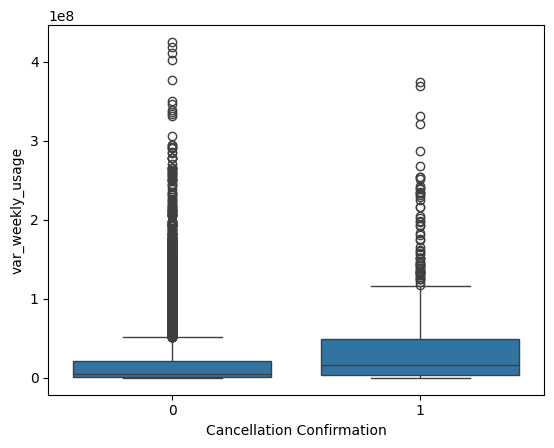

In [109]:
sns.boxplot(df_a, x = "Cancellation Confirmation", y = "var_weekly_usage")

In [110]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [121]:
clf = HistGradientBoostingClassifier(max_depth=100, class_weight={np.int8(0): np.float64(0.5250034018233773),
 np.int8(1): np.float64(10.498639455782312)})

#clf = HistGradientBoostingClassifier(class_weight=cw)

In [112]:
df_a = df_a.rename(columns={
    40: "40",
    41: "41",
    42: "42",
    43: "43",
    44: "44",
    45: "45"
})

In [113]:
df_a.columns

Index(['userId', '40', '41', '42', '43', '44', '45', 'delta_week_45_40',
       'delta_week_45_41', 'delta_week_45_42', 'delta_week_45_43',
       'delta_week_45_44', '%_delta_week_45_40', '%_delta_week_45_41',
       '%_delta_week_45_42', '%_delta_week_45_43', '%_delta_week_45_44',
       'mean_weekly_delta', 'median_weekly_delta', 'var_weekly_delta',
       'mean_weekly_usage', 'median_weekly_usage', 'var_weekly_usage',
       'mean_weekly_delta_%', 'median_weekly_delta_%', 'var_weekly_delta_%',
       'Cancellation Confirmation'],
      dtype='object')

In [114]:
X = df_a[['40', '41', '42', '43', '44', '45', 'delta_week_45_40',
       'delta_week_45_41', 'delta_week_45_42', 'delta_week_45_43',
       'delta_week_45_44', '%_delta_week_45_40', '%_delta_week_45_41',
       '%_delta_week_45_42', '%_delta_week_45_43', '%_delta_week_45_44',
       'mean_weekly_delta', 'median_weekly_delta', 'var_weekly_delta',
       'mean_weekly_usage', 'median_weekly_usage', 'var_weekly_usage',
       'mean_weekly_delta_%', 'median_weekly_delta_%', 'var_weekly_delta_%']]

y = df_a["Cancellation Confirmation"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [115]:
classes = np.unique(y)
w = compute_class_weight("balanced", classes=classes, y=y)

In [116]:
class_weight = dict(zip(classes, w))

In [117]:
class_weight

{np.int8(0): np.float64(0.5250034018233773),
 np.int8(1): np.float64(10.498639455782312)}

In [122]:
clf.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,100
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [123]:
clf.score(X_test, y_test)

0.7305001295672454

In [124]:
pred = clf.predict(X_test)

confusion_matrix(y_test, pred)

array([[2736,  940],
       [ 100,   83]])

In [125]:
df_y[df_y["Cancellation Confirmation"] == 1]

,userId,Cancellation Confirmation
17,1240184,1
30,1418529,1
41,1642905,1
54,1162900,1
57,1202559,1
...,...,...
14701,1381416,1
14800,1333772,1
14858,1689553,1
14860,1181686,1


In [126]:
from xgboost import XGBClassifier

In [127]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11574 entries, 12859 to 13979
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   40                     11574 non-null  float64
 1   41                     11574 non-null  float64
 2   42                     11574 non-null  float64
 3   43                     11574 non-null  float64
 4   44                     11574 non-null  float64
 5   45                     11574 non-null  float64
 6   delta_week_45_40       11574 non-null  float64
 7   delta_week_45_41       11574 non-null  float64
 8   delta_week_45_42       11574 non-null  float64
 9   delta_week_45_43       11574 non-null  float64
 10  delta_week_45_44       11574 non-null  float64
 11  %_delta_week_45_40     10601 non-null  object 
 12  %_delta_week_45_41     10862 non-null  object 
 13  %_delta_week_45_42     10897 non-null  object 
 14  %_delta_week_45_43     10942 non-null  object 
 15  %_d

In [130]:
X_train["%_delta_week_45_40"] = pd.to_numeric(X_train["%_delta_week_45_40"])
X_train["%_delta_week_45_41"] = pd.to_numeric(X_train["%_delta_week_45_41"])
X_train["%_delta_week_45_42"] = pd.to_numeric(X_train["%_delta_week_45_42"])
X_train["%_delta_week_45_43"] = pd.to_numeric(X_train["%_delta_week_45_43"])

X_train["mean_weekly_delta_%"] = pd.to_numeric(X_train["mean_weekly_delta_%"])
X_train["median_weekly_delta_%"] = pd.to_numeric(X_train["median_weekly_delta_%"])
X_train["var_weekly_delta_%"] = pd.to_numeric(X_train["var_weekly_delta_%"])



X_test["%_delta_week_45_40"] = pd.to_numeric(X_test["%_delta_week_45_40"])
X_test["%_delta_week_45_41"] = pd.to_numeric(X_test["%_delta_week_45_41"])
X_test["%_delta_week_45_42"] = pd.to_numeric(X_test["%_delta_week_45_42"])
X_test["%_delta_week_45_43"] = pd.to_numeric(X_test["%_delta_week_45_43"])

X_test["mean_weekly_delta_%"] = pd.to_numeric(X_test["mean_weekly_delta_%"])
X_test["median_weekly_delta_%"] = pd.to_numeric(X_test["median_weekly_delta_%"])
X_test["var_weekly_delta_%"] = pd.to_numeric(X_test["var_weekly_delta_%"])

In [142]:
# 3) Model
#xgb = XGBClassifier(
#    n_estimators=500,
#    learning_rate=0.05,
#    max_depth=6,
#    subsample=0.8,
#    colsample_bytree=0.8,
#    reg_lambda=1.0,
#    random_state=42,
#    n_jobs=-1,
#    eval_metric="auc"  # avoids warning in many setups
#)
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
spw = n_neg / max(n_pos, 1)

print(n_pos)
print(n_neg)

print((n_pos / n_neg) * 100)

xgb = XGBClassifier(eval_metric = "aucpr", scale_pos_weight = spw)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

confusion_matrix(y_test, pred)




552
11022
5.008165487207403


array([[3529,  147],
       [ 173,   10]])